In [18]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import nbformat
import ast
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [19]:
# file names
data_file = "Transformed_TGSIM_Foggy_Bottom_200sec.xlsx"
polygon_file = "Polygons.ipynb"

# output files
dataset_summary_file = "dataset_description_summary.csv"
group_summary_file = "agent_group_summary.csv"
decel_agent_file = "deceleration_by_agent.csv"
decel_group_file = "deceleration_by_group.csv"
lane_summary_file = "lane_speed_summary.csv"

In [20]:
# load the main dataset
df = pd.read_excel(data_file)

# clean column names
df.columns = df.columns.str.strip()

# sort by id and time
df = df.sort_values(["id", "time"]).reset_index(drop=True)

# quick check
print(df.head())
print(df.columns.tolist())

    id    time     xloc_kf     yloc_kf  lane_kf  speed_kf_x  speed_kf_y  acceleration_kf_x  acceleration_kf_y  length_smoothed  width_smoothed  type_most_common
0  165  3700.0  183.966348  308.305096       36    0.108236    6.005233           0.018661           0.802440             15.0        2.413078                 7
1  165  3700.1  183.978291  308.896475       36    0.119433    5.913793           0.111968          -0.914408             15.0        2.413078                 7
2  165  3700.2  183.991354  309.478151       36    0.130630    5.816753           0.111968          -0.970392             15.0        2.413078                 7
3  165  3700.3  184.004604  310.048069       36    0.132496    5.699187           0.018661          -1.175667             15.0        2.413078                 7
4  165  3700.4  184.017107  310.605112       36    0.125031    5.570423          -0.074646          -1.287635             15.0        2.413078                 7
['id', 'time', 'xloc_kf', 'yloc_kf

In [21]:
# readable labels for agent types
type_map = {
    0: "Pedestrian",
    1: "Bicycle",
    2: "Scooter",
    3: "Passenger Car",
    4: "Automated Vehicle",
    5: "Motorcycle",
    6: "Bus",
    7: "Truck"
}

df["agent_type"] = df["type_most_common"].map(type_map)

# use all agent types for the report
df["report_group"] = df["agent_type"]

# keep a quick count
print(df["report_group"].value_counts(dropna=False))

report_group
Passenger Car        47143
Pedestrian           18290
Truck                 2724
Automated Vehicle     1975
Bicycle                498
Bus                    495
Scooter                210
Motorcycle              26
Name: count, dtype: int64


In [22]:
# speed, acceleration, and change values
df["speed_total"] = np.sqrt(df["speed_kf_x"]**2 + df["speed_kf_y"]**2)
df["accel_total"] = np.sqrt(df["acceleration_kf_x"]**2 + df["acceleration_kf_y"]**2)

df["dt"] = df.groupby("id")["time"].diff()
df["speed_change"] = df.groupby("id")["speed_total"].diff()
df["signed_accel"] = df["speed_change"] / df["dt"]

df["signed_accel"] = df["signed_accel"].replace([np.inf, -np.inf], np.nan)

# optional extra measure
df["jerk"] = df.groupby("id")["signed_accel"].diff() / df["dt"]
df["jerk"] = df["jerk"].replace([np.inf, -np.inf], np.nan)

print(df[["id", "time", "speed_total", "signed_accel", "jerk"]].head(10))

    id    time  speed_total  signed_accel      jerk
0  165  3700.0     6.006209           NaN       NaN
1  165  3700.1     5.914998     -0.912102       NaN
2  165  3700.2     5.818220     -0.967785 -0.556825
3  165  3700.3     5.700727     -1.174934 -2.071494
4  165  3700.4     5.571826     -1.289005 -1.140706
5  165  3700.5     5.433561     -1.382653 -0.936481
6  165  3700.6     5.289596     -1.439647 -0.569939
7  165  3700.7     5.143763     -1.458332 -0.186858
8  165  3700.8     4.994213     -1.495495 -0.371625
9  165  3700.9     4.844702     -1.495112  0.003833


In [23]:
# dataset description table
dataset_summary = pd.DataFrame({
    "column_name": df.columns,
    "data_type": [str(df[col].dtype) for col in df.columns],
    "non_null_count": [df[col].notna().sum() for col in df.columns],
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
})

print(dataset_summary)
dataset_summary.to_csv(dataset_summary_file, index=False)

          column_name data_type  non_null_count  unique_values
0                  id     int64           71361            564
1                time   float64           71361           2001
2             xloc_kf   float64           71361          48856
3             yloc_kf   float64           71361          51375
4             lane_kf     int64           71361             46
5          speed_kf_x   float64           71361          17598
6          speed_kf_y   float64           71361          25575
7   acceleration_kf_x   float64           71361          22710
8   acceleration_kf_y   float64           71361          26575
9     length_smoothed   float64           71361             31
10     width_smoothed   float64           71361             73
11   type_most_common     int64           71361              8
12         agent_type    object           71361              8
13       report_group    object           71361              8
14        speed_total   float64           71361        

In [24]:
# keep all agent groups separately
main_df = df.copy()

# use actual agent types as report groups
main_df["report_group"] = main_df["agent_type"]

# verify groups
print(main_df["report_group"].unique())
print(main_df["report_group"].value_counts())

['Truck' 'Passenger Car' 'Bus' 'Automated Vehicle' 'Motorcycle'
 'Pedestrian' 'Bicycle' 'Scooter']
report_group
Passenger Car        47143
Pedestrian           18290
Truck                 2724
Automated Vehicle     1975
Bicycle                498
Bus                    495
Scooter                210
Motorcycle              26
Name: count, dtype: int64


In [25]:
# summary stats by group
group_summary = main_df.groupby("report_group").agg(
    observations=("id", "size"),
    unique_agents=("id", "nunique"),
    mean_speed=("speed_total", "mean"),
    median_speed=("speed_total", "median"),
    std_speed=("speed_total", "std"),
    mean_signed_accel=("signed_accel", "mean"),
    median_signed_accel=("signed_accel", "median"),
    std_signed_accel=("signed_accel", "std"),
    mean_accel_magnitude=("accel_total", "mean"),
    median_accel_magnitude=("accel_total", "median"),
    mean_jerk=("jerk", "mean"),
    median_jerk=("jerk", "median")
).reset_index()

print(group_summary)
group_summary.to_csv(group_summary_file, index=False)

        report_group  observations  unique_agents  mean_speed  median_speed  std_speed  mean_signed_accel  median_signed_accel  std_signed_accel  mean_accel_magnitude  median_accel_magnitude  \
0  Automated Vehicle          1975              1    2.470593      2.683821   2.144249           0.009448         0.000000e+00          0.491654              0.383804                0.187545   
1            Bicycle           498              8    1.727159      0.540683   2.088950          -0.076744        -9.282047e-04          0.825381              0.509144                0.083456   
2                Bus           495              2    1.830558      0.464234   2.445692           0.096484         1.413337e-02          0.842237              0.570656                0.211129   
3         Motorcycle            26              1    5.381609      5.545800   0.600524          -0.073597        -1.115309e-02          1.723760              1.421059                1.843909   
4      Passenger Car         4

In [26]:
# summary stats by group
group_summary = main_df.groupby("report_group").agg(
    observations=("id", "size"),
    unique_agents=("id", "nunique"),
    mean_speed=("speed_total", "mean"),
    median_speed=("speed_total", "median"),
    std_speed=("speed_total", "std"),
    mean_signed_accel=("signed_accel", "mean"),
    median_signed_accel=("signed_accel", "median"),
    std_signed_accel=("signed_accel", "std"),
    mean_accel_magnitude=("accel_total", "mean"),
    median_accel_magnitude=("accel_total", "median"),
    mean_jerk=("jerk", "mean"),
    median_jerk=("jerk", "median")
).reset_index()

print(group_summary)
group_summary.to_csv(group_summary_file, index=False)

        report_group  observations  unique_agents  mean_speed  median_speed  std_speed  mean_signed_accel  median_signed_accel  std_signed_accel  mean_accel_magnitude  median_accel_magnitude  \
0  Automated Vehicle          1975              1    2.470593      2.683821   2.144249           0.009448         0.000000e+00          0.491654              0.383804                0.187545   
1            Bicycle           498              8    1.727159      0.540683   2.088950          -0.076744        -9.282047e-04          0.825381              0.509144                0.083456   
2                Bus           495              2    1.830558      0.464234   2.445692           0.096484         1.413337e-02          0.842237              0.570656                0.211129   
3         Motorcycle            26              1    5.381609      5.545800   0.600524          -0.073597        -1.115309e-02          1.723760              1.421059                1.843909   
4      Passenger Car         4

In [27]:
# speed consistency by lane / polygon id
lane_summary = main_df.groupby(["lane_kf", "report_group"]).agg(
    observations=("id", "size"),
    unique_agents=("id", "nunique"),
    mean_speed=("speed_total", "mean"),
    median_speed=("speed_total", "median"),
    std_speed=("speed_total", "std"),
    mean_signed_accel=("signed_accel", "mean")
).reset_index()

print(lane_summary.head(20))
lane_summary.to_csv(lane_summary_file, index=False)

    lane_kf       report_group  observations  unique_agents  mean_speed  median_speed  std_speed  mean_signed_accel
0         1  Automated Vehicle            25              1    6.880175      6.933618   0.274558          -0.066325
1         1            Bicycle            59              2    4.546281      4.075815   1.419090          -0.365498
2         1                Bus            64              2    4.864007      5.404060   1.778751           1.119486
3         1         Motorcycle            22              1    5.532999      5.727560   0.507460           0.380983
4         1      Passenger Car          1054             68    9.790424     10.362514   3.941144           0.449803
5         1         Pedestrian          1256             28    1.072951      1.151666   0.832248          -0.028365
6         1            Scooter            17              2    3.513818      3.512036   0.537129           1.206159
7         1              Truck            18              1    8.654715 

In [28]:
# make all agent types show separately
group_summary = main_df.groupby("report_group").agg(
    mean_speed=("speed_total", "mean"),
    mean_signed_accel=("signed_accel", "mean")
).reset_index()

print(group_summary)

        report_group  mean_speed  mean_signed_accel
0  Automated Vehicle    2.470593           0.009448
1            Bicycle    1.727159          -0.076744
2                Bus    1.830558           0.096484
3         Motorcycle    5.381609          -0.073597
4      Passenger Car    3.256133           0.025707
5         Pedestrian    1.302075           0.012156
6            Scooter    4.426109           0.178299
7              Truck    0.370550           0.007962


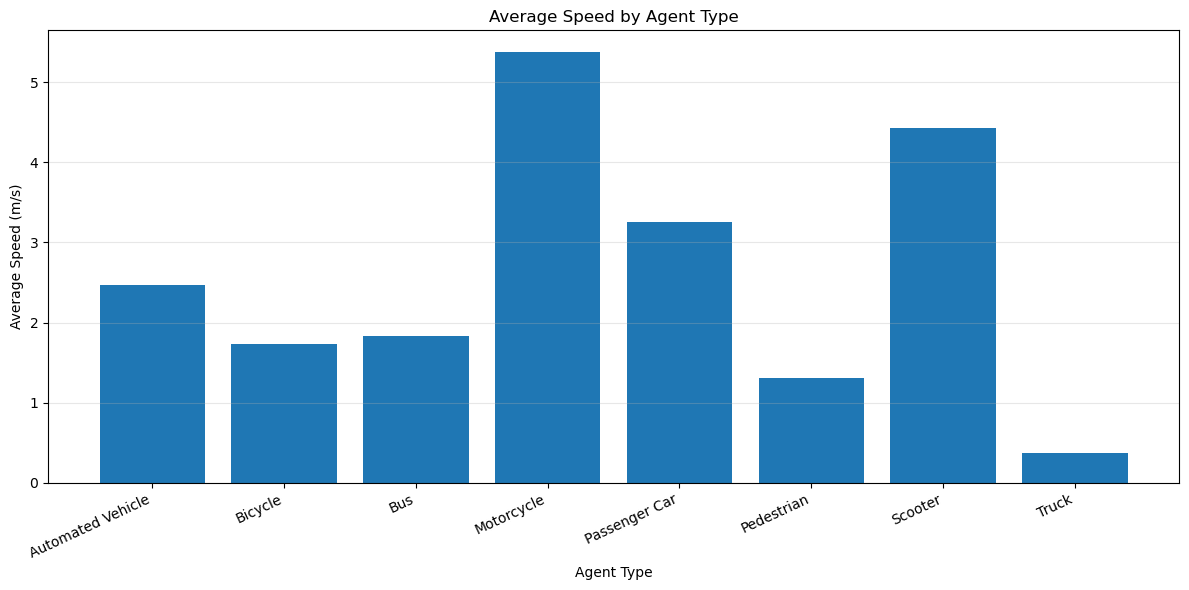

In [29]:
# average speed plot
plt.figure(figsize=(12, 6))
plt.bar(group_summary["report_group"], group_summary["mean_speed"])

plt.title("Average Speed by Agent Type")
plt.xlabel("Agent Type")
plt.ylabel("Average Speed (m/s)")

plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

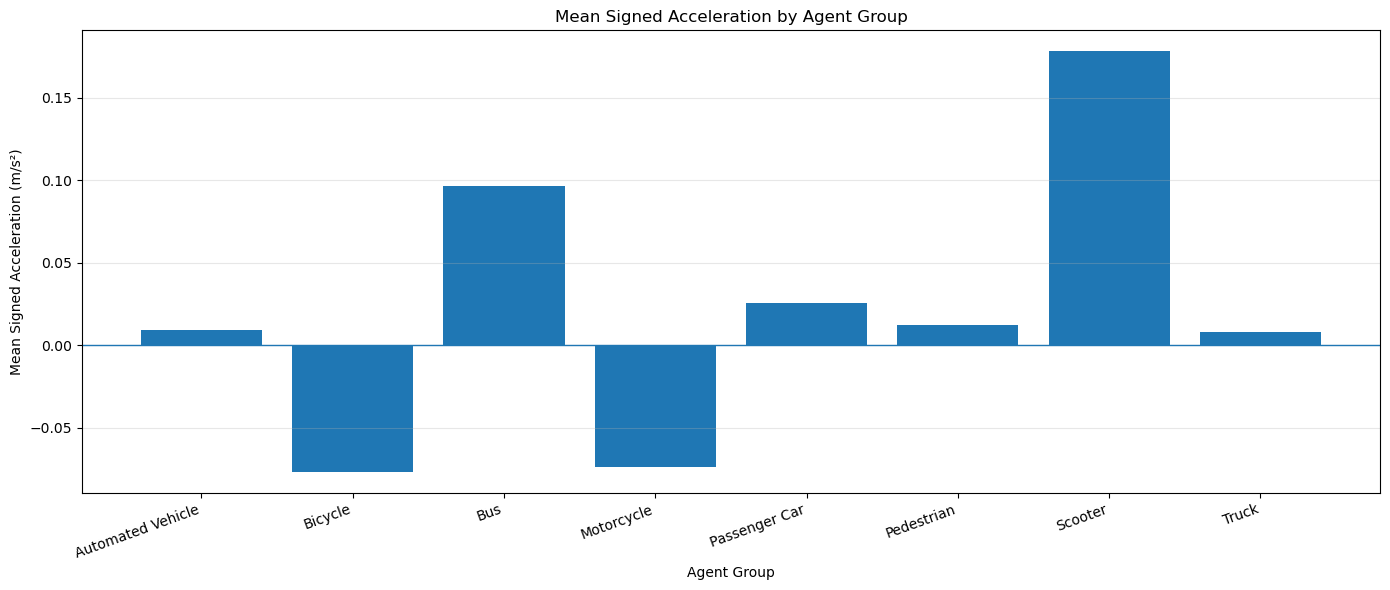

In [30]:
# mean signed acceleration plot
plt.figure(figsize=(14, 6))

plt.bar(
    group_summary["report_group"],
    group_summary["mean_signed_accel"]
)

plt.title("Mean Signed Acceleration by Agent Group")
plt.xlabel("Agent Group")
plt.ylabel("Mean Signed Acceleration (m/s²)")

plt.axhline(0, linewidth=1)

plt.xticks(rotation=20, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

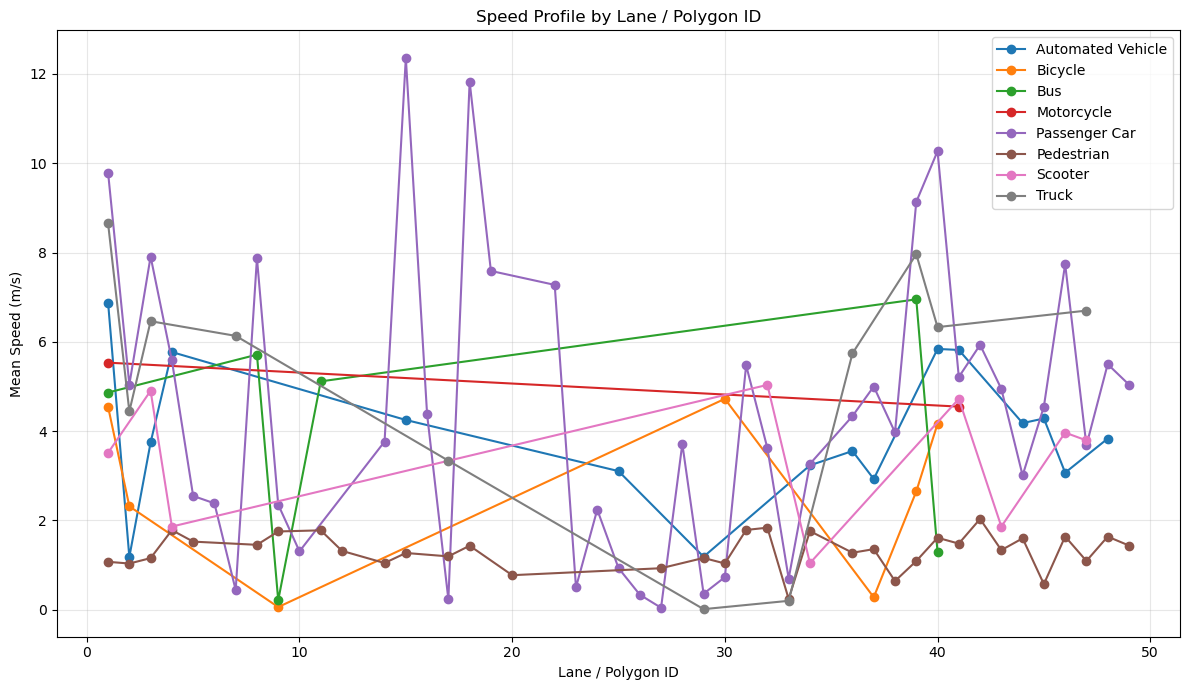

In [31]:
# lane speed profile plot
plt.figure(figsize=(12, 7))

for group_name in lane_summary["report_group"].dropna().unique():
    temp = lane_summary[lane_summary["report_group"] == group_name].sort_values("lane_kf")
    plt.plot(temp["lane_kf"], temp["mean_speed"], marker="o", label=group_name)

plt.title("Speed Profile by Lane / Polygon ID")
plt.xlabel("Lane / Polygon ID")
plt.ylabel("Mean Speed (m/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# threshold for strong deceleration
decel_threshold = -2.0

# flag rows with strong deceleration
main_df["hard_decel_flag"] = main_df["signed_accel"] <= decel_threshold

# count per agent
decel_by_agent = main_df.groupby(["id", "report_group"]).agg(
    hard_decel_events=("hard_decel_flag", "sum"),
    mean_speed=("speed_total", "mean"),
    mean_signed_accel=("signed_accel", "mean")
).reset_index()

# count per group
decel_by_group = decel_by_agent.groupby("report_group").agg(
    agents_in_group=("id", "nunique"),
    total_hard_decel_events=("hard_decel_events", "sum"),
    mean_hard_decel_events_per_agent=("hard_decel_events", "mean"),
    median_hard_decel_events_per_agent=("hard_decel_events", "median")
).reset_index()

print(decel_by_group)

        report_group  agents_in_group  total_hard_decel_events  mean_hard_decel_events_per_agent  median_hard_decel_events_per_agent
0  Automated Vehicle                1                        1                          1.000000                                 1.0
1            Bicycle                8                       15                          1.875000                                 0.0
2                Bus                2                       15                          7.500000                                 7.5
3         Motorcycle                1                        4                          4.000000                                 4.0
4      Passenger Car              157                     2077                         13.229299                                16.0
5         Pedestrian              380                        0                          0.000000                                 0.0
6            Scooter                8                        9       

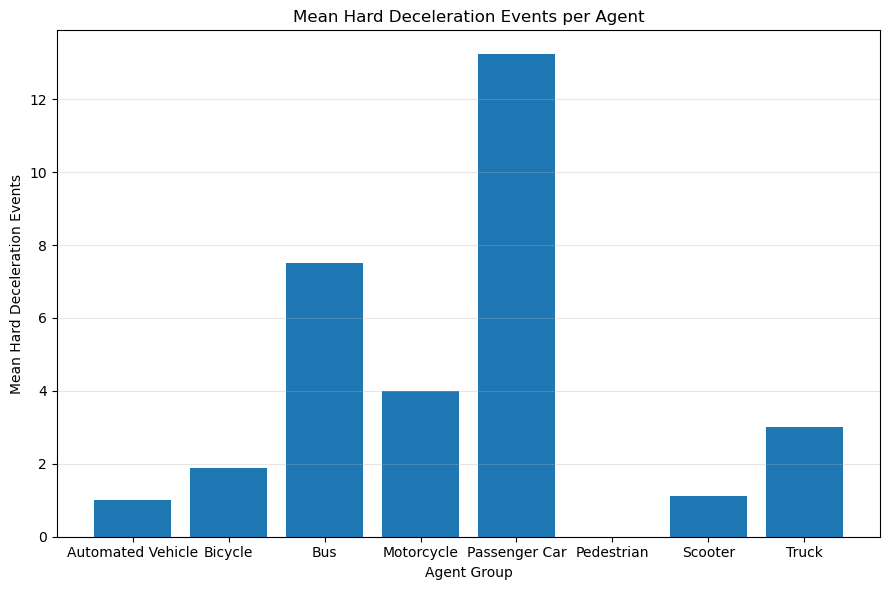

In [33]:
# hard deceleration events plot
plt.figure(figsize=(9, 6))
plt.bar(decel_by_group["report_group"], decel_by_group["mean_hard_decel_events_per_agent"])
plt.title("Mean Hard Deceleration Events per Agent")
plt.xlabel("Agent Group")
plt.ylabel("Mean Hard Deceleration Events")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

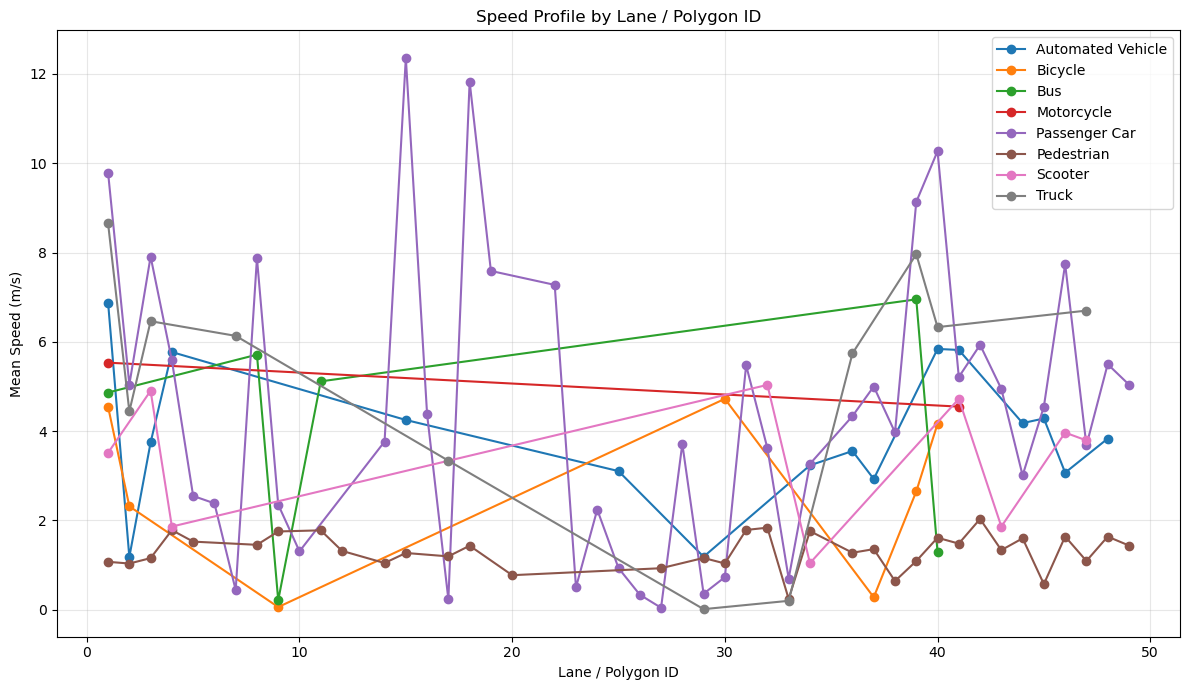

In [34]:
# lane speed profile plot
plt.figure(figsize=(12, 7))

for group_name in lane_summary["report_group"].dropna().unique():
    temp = lane_summary[lane_summary["report_group"] == group_name].sort_values("lane_kf")
    plt.plot(temp["lane_kf"], temp["mean_speed"], marker="o", label=group_name)

plt.title("Speed Profile by Lane / Polygon ID")
plt.xlabel("Lane / Polygon ID")
plt.ylabel("Mean Speed (m/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# load polygon data from the notebook
with open(polygon_file, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

all_code = "\n".join(cell.source for cell in nb.cells if cell.cell_type == "code")

match = re.search(r"polygons\s*=\s*(\{.*\})", all_code, re.S)

if match is None:
    raise ValueError("Could not find polygons dictionary in Polygons.ipynb")

polygons = ast.literal_eval(match.group(1))

print(type(polygons))
print(list(polygons.keys())[:10])

<class 'dict'>
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


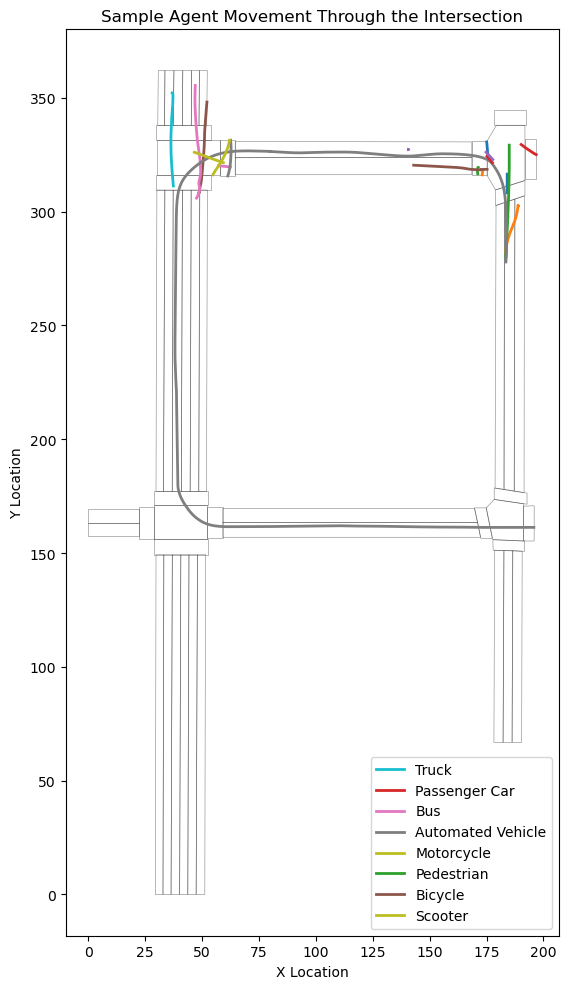

In [42]:
# sample movement plot on top of polygon outlines
fig, ax = plt.subplots(figsize=(10, 10))

# draw polygon outlines
for poly_id, coords in polygons.items():
    coords_array = np.array(coords)
    patch = MplPolygon(coords_array, closed=True, fill=False, linewidth=0.5, alpha=0.4)
    ax.add_patch(patch)

# choose a few sample ids from each main group
sample_ids = []

for group_name in main_df["report_group"].dropna().unique():
    ids_here = main_df.loc[main_df["report_group"] == group_name, "id"].drop_duplicates().head(3).tolist()
    sample_ids.extend(ids_here)

plot_df = main_df[main_df["id"].isin(sample_ids)].copy()

for agent_id in plot_df["id"].unique():
    temp = plot_df[plot_df["id"] == agent_id].sort_values("time")
    group_name = temp["report_group"].iloc[0]
    ax.plot(temp["xloc_kf"], temp["yloc_kf"], linewidth=2, label=group_name)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

ax.set_title("Sample Agent Movement Through the Intersection")
ax.set_xlabel("X Location")
ax.set_ylabel("Y Location")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()
plt.close()

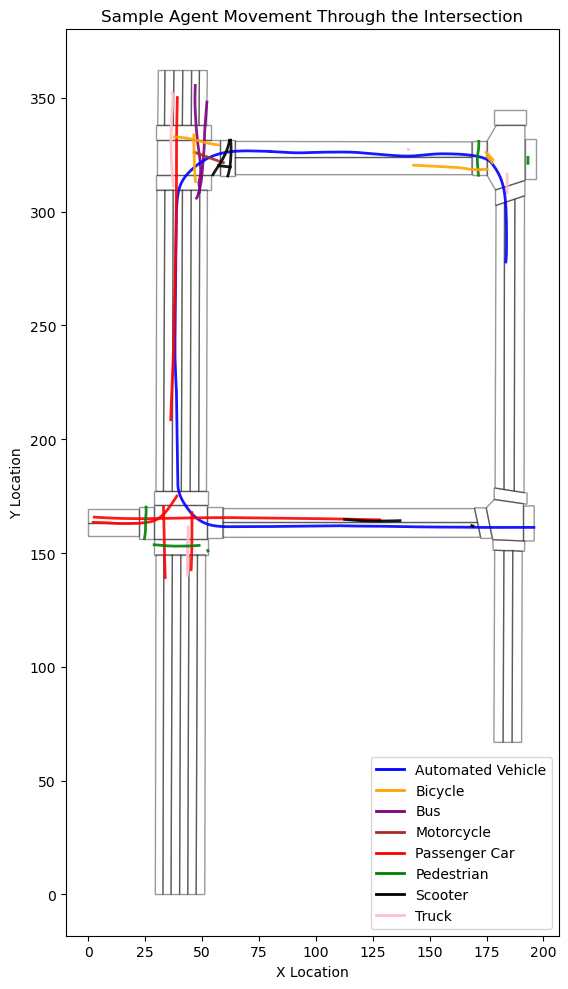

In [43]:
# sample movement plot with random agents and group colors
fig, ax = plt.subplots(figsize=(10, 10))

color_map = {
    "Automated Vehicle": "blue",
    "Bicycle": "orange",
    "Bus": "purple",
    "Motorcycle": "brown",
    "Passenger Car": "red",
    "Pedestrian": "green",
    "Scooter": "black",
    "Truck": "pink"
}

# draw polygons first
for poly_id, coords in polygons.items():
    patch = MplPolygon(coords, closed=True, fill=False, alpha=0.4)
    ax.add_patch(patch)

# pick random sample ids from each group
sample_ids = []

for group_name in main_df["report_group"].dropna().unique():
    group_ids = main_df.loc[main_df["report_group"] == group_name, "id"].drop_duplicates()
    ids_here = group_ids.sample(n=min(5, len(group_ids)), random_state=42).tolist()
    sample_ids.extend(ids_here)

plot_df = main_df[main_df["id"].isin(sample_ids)].copy()

# plot each sampled agent
for agent_id in plot_df["id"].unique():
    temp = plot_df[plot_df["id"] == agent_id].sort_values("time")
    group_name = temp["report_group"].iloc[0]

    ax.plot(
        temp["xloc_kf"],
        temp["yloc_kf"],
        color=color_map.get(group_name, "gray"),
        linewidth=2,
        alpha=0.9
    )

# legend
for group_name, color in color_map.items():
    if group_name in main_df["report_group"].unique():
        ax.plot([], [], color=color, linewidth=2, label=group_name)

ax.legend()

ax.set_title("Sample Agent Movement Through the Intersection")
ax.set_xlabel("X Location")
ax.set_ylabel("Y Location")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [44]:
# average speed inside each lane for all groups
lane_pivot = lane_summary.pivot(index="lane_kf", columns="report_group", values="mean_speed")

print(lane_pivot.head(20))

report_group  Automated Vehicle   Bicycle       Bus  Motorcycle  Passenger Car  Pedestrian   Scooter     Truck
lane_kf                                                                                                       
1                      6.880175  4.546281  4.864007    5.532999       9.790424    1.072951  3.513818  8.654715
2                      1.180643  2.315993       NaN         NaN       5.043271    1.034401       NaN  4.442773
3                      3.745208       NaN       NaN         NaN       7.909291    1.156026  4.903739  6.461660
4                      5.770939       NaN       NaN         NaN       5.582109    1.782479  1.862687       NaN
5                           NaN       NaN       NaN         NaN       2.548464    1.525341       NaN       NaN
6                           NaN       NaN       NaN         NaN       2.382715         NaN       NaN       NaN
7                           NaN       NaN       NaN         NaN       0.440329         NaN       NaN  6.133613
8

In [39]:
# top lanes with the largest speed differences
lane_compare = lane_pivot.copy()

# only keep rows where at least two groups are present
lane_compare["max_speed"] = lane_compare.max(axis=1)
lane_compare["min_speed"] = lane_compare.min(axis=1)
lane_compare["speed_range"] = lane_compare["max_speed"] - lane_compare["min_speed"]

lane_compare = lane_compare.sort_values("speed_range", ascending=False)

print(lane_compare.head(15))

report_group  Automated Vehicle   Bicycle       Bus  Motorcycle  Passenger Car  Pedestrian   Scooter     Truck  max_speed  min_speed  speed_range
lane_kf                                                                                                                                          
15                     4.249647       NaN       NaN         NaN      12.358909    1.270713       NaN       NaN  12.358909   1.270713    11.088196
18                          NaN       NaN       NaN         NaN      11.828353    1.433504       NaN       NaN  11.828353   1.433504    10.394849
40                     5.840937  4.163432  1.292381         NaN      10.269935    1.612276       NaN  6.329272  10.269935   1.292381     8.977553
1                      6.880175  4.546281  4.864007    5.532999       9.790424    1.072951  3.513818  8.654715   9.790424   1.072951     8.717473
39                          NaN  2.648848  6.951217         NaN       9.133452    1.090727       NaN  7.962684   9.133452   

In [40]:
# simple written summary values to copy into the report
fastest_group = group_summary.loc[group_summary["mean_speed"].idxmax(), "report_group"]
slowest_group = group_summary.loc[group_summary["mean_speed"].idxmin(), "report_group"]

most_decel_group = decel_by_group.loc[decel_by_group["mean_hard_decel_events_per_agent"].idxmax(), "report_group"]
least_decel_group = decel_by_group.loc[decel_by_group["mean_hard_decel_events_per_agent"].idxmin(), "report_group"]

print("Fastest average group:", fastest_group)
print("Slowest average group:", slowest_group)
print("Most hard deceleration events per agent:", most_decel_group)
print("Fewest hard deceleration events per agent:", least_decel_group)

Fastest average group: Motorcycle
Slowest average group: Truck
Most hard deceleration events per agent: Passenger Car
Fewest hard deceleration events per agent: Pedestrian


<Figure size 1000x600 with 0 Axes>

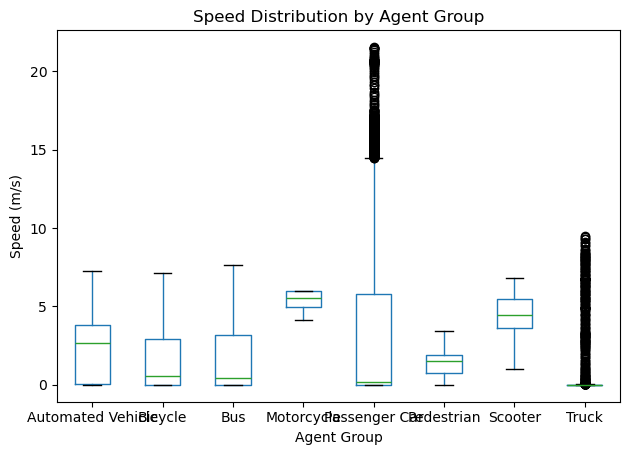

In [41]:
# boxplot for speed spread
plt.figure(figsize=(10, 6))

main_df.boxplot(column="speed_total", by="report_group", grid=False)

plt.title("Speed Distribution by Agent Group")
plt.suptitle("")
plt.xlabel("Agent Group")
plt.ylabel("Speed (m/s)")
plt.tight_layout()
plt.show()